In [6]:
import glob
import os
import sys
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))
from src.utils import AudioPreprocessor

preprocessor = AudioPreprocessor()

with tf.device('/CPU:0'):
	model = tf.keras.models.load_model('../models/model.keras')

normal_files = glob.glob('../data/raw/pump/id_*/normal/*.wav')
abnormal_files = glob.glob('../data/raw/pump/id_*/abnormal/*.wav')
normal_files = random.sample(normal_files, 200)
abnormal_files = random.sample(abnormal_files, 200)

print(f'Testing with {len(normal_files)} normal files and {len(abnormal_files)} abnormal files.')

Testing with 200 normal files and 200 abnormal files.


In [7]:
import librosa as lr

def get_reconstruction_error(file_path):
	spec = preprocessor.transform(file_path)
	if spec.shape[1] != 313:
		spec = lr.util.fix_length(spec, size=313, axis=1)

	input_data = spec[np.newaxis, ..., np.newaxis]
	with tf.device('/CPU:0'):
		reconstructed = model.predict(input_data, verbose=0)

	mse = preprocessor.calculate_reconstruction_error(input_data, reconstructed)
	return mse

# model.summary()
normal_errors = [get_reconstruction_error(f) for f in normal_files]
abnormal_errors = [get_reconstruction_error(f) for f in abnormal_files]

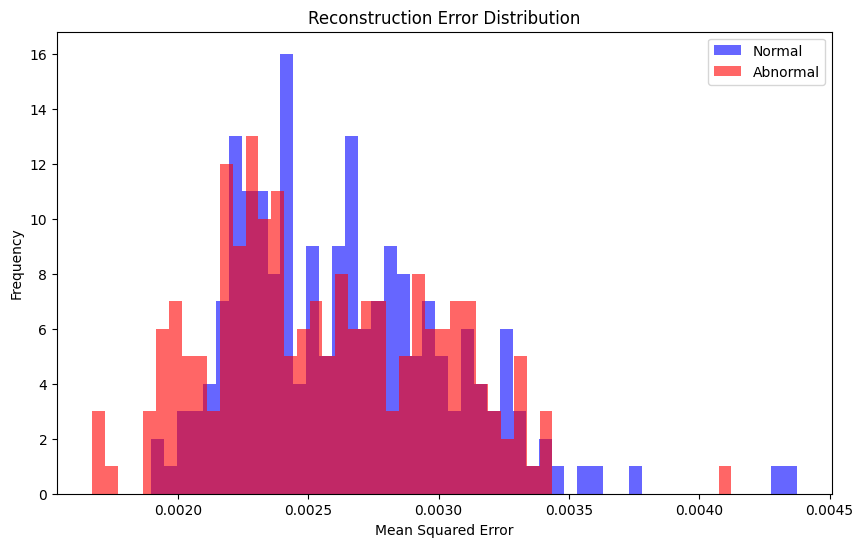

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(normal_errors, bins=50, alpha=0.6, label='Normal', color='blue')
plt.hist(abnormal_errors, bins=50, alpha=0.6, label='Abnormal', color='red')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [13]:
mean_err = np.mean(normal_errors)
std_err = np.std(normal_errors)
threshold = mean_err + 3 * std_err
print(f'Calculated threshold: {threshold:.4f}')

Calculated threshold: 0.0039


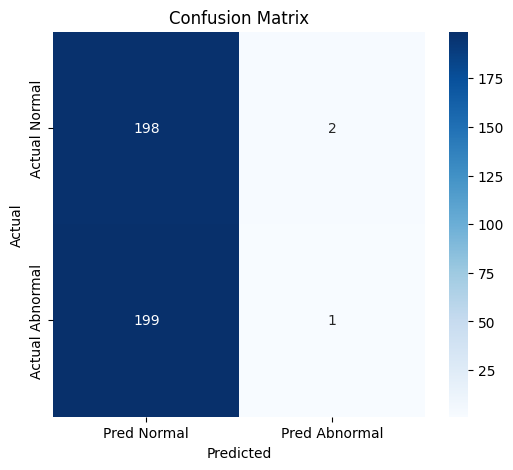

              precision    recall  f1-score   support

      Normal       0.50      0.99      0.66       200
    Abnormal       0.33      0.01      0.01       200

    accuracy                           0.50       400
   macro avg       0.42      0.50      0.34       400
weighted avg       0.42      0.50      0.34       400



In [14]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

y_true = [0] * len(normal_errors) + [1] * len(abnormal_errors)

all_errors = normal_errors + abnormal_errors

# Abnormal = 1, Normal = 0
y_pred = [1 if err > threshold else 0 for err in all_errors]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
	cm, annot=True, fmt='d', cmap='Blues', 
	xticklabels=['Pred Normal', 'Pred Abnormal'],
	yticklabels=['Actual Normal', 'Actual Abnormal']
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal']))

The reconstruction error distribution and the confusion matrix shows a critical failure in the model's ability to detect anomalies. Still a lot of work to be done to make the model learn the distinct features of a failing pump instead of predicting everything as normal.